In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [60]:
_data = pd.read_csv('Офіційний курс гривні щодо іноземних валют.csv')
_data.head(10)

,Дата,Час,Код цифровий,Код літерний,Кількість одиниць,Назва валюти,"Офіційний курс гривні, грн"
0,01.01.2022,0.0,840,USD,1,Долар США,27.2782
1,02.01.2022,0.0,840,USD,1,Долар США,27.2782
2,03.01.2022,0.0,840,USD,1,Долар США,27.2782
3,04.01.2022,0.0,840,USD,1,Долар США,27.2782
4,05.01.2022,0.0,840,USD,1,Долар США,27.2976
5,06.01.2022,0.0,840,USD,1,Долар США,27.4551
6,07.01.2022,0.0,840,USD,1,Долар США,27.4551
7,08.01.2022,0.0,840,USD,1,Долар США,27.4551
8,09.01.2022,0.0,840,USD,1,Долар США,27.4551
9,10.01.2022,0.0,840,USD,1,Долар США,27.4977


In [61]:
_data[['Дата', 'Офіційний курс гривні, грн']].head(10)

,Дата,"Офіційний курс гривні, грн"
0,01.01.2022,27.2782
1,02.01.2022,27.2782
2,03.01.2022,27.2782
3,04.01.2022,27.2782
4,05.01.2022,27.2976
5,06.01.2022,27.4551
6,07.01.2022,27.4551
7,08.01.2022,27.4551
8,09.01.2022,27.4551
9,10.01.2022,27.4977


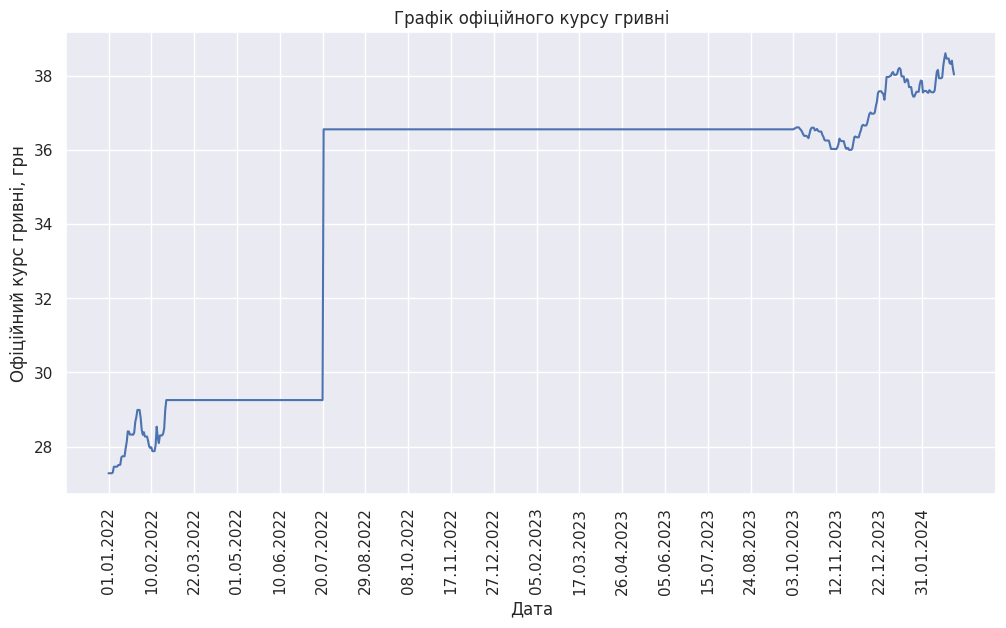

In [62]:
date = _data['Дата'].to_numpy()
value = _data['Офіційний курс гривні, грн'].to_numpy()
sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 6))
plt.plot(date, value)
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Графік офіційного курсу гривні')
plt.xticks(date[::40], rotation=90)
plt.show()



Best : alpha=0.5, beta=0.6, gamma=0.1
Best MSE: 0.1544448252882917
Best MAE: 0.31389133624831117


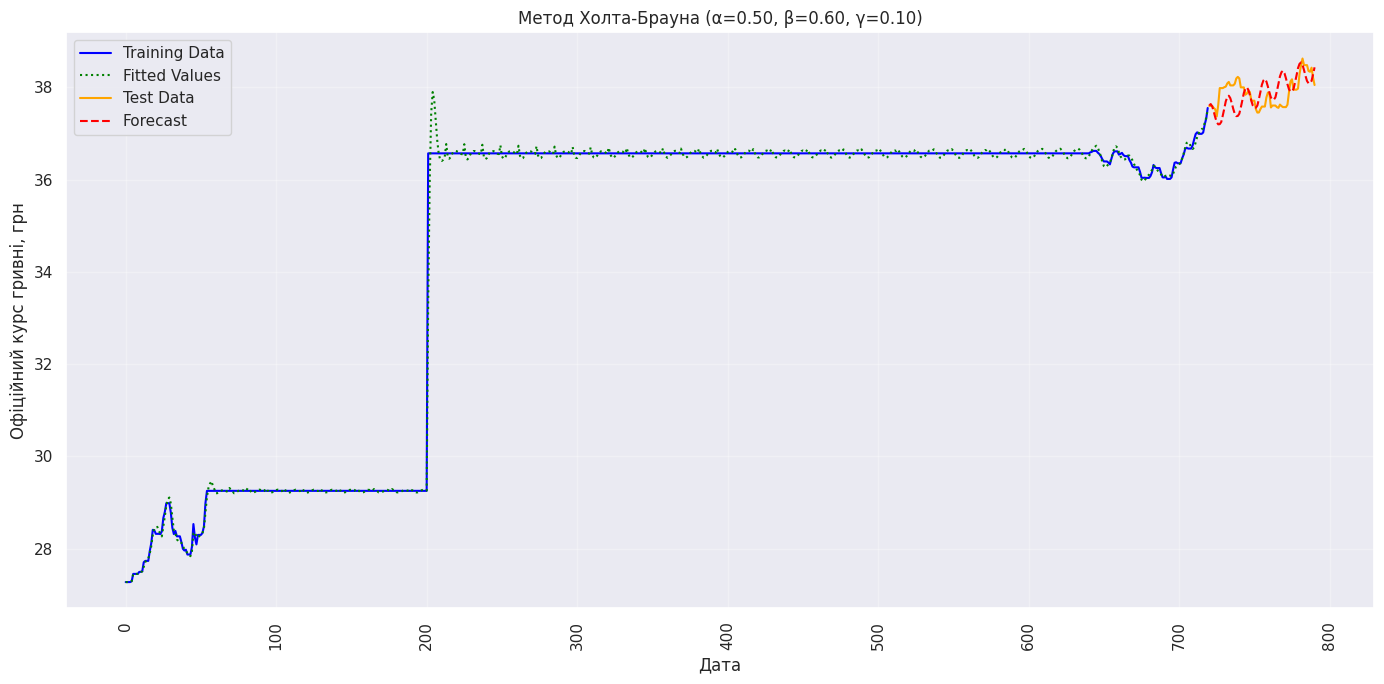


Метрики при тренуванні:
MSE: 0.025627
RMSE: 0.160085
MAE: 0.061626
MAPE: 0.175617

Метрики при прогнозуванні :
MSE: 0.154445
RMSE: 0.392995
MAE: 0.313891
MAPE: 0.828507


In [68]:
def holt_winters_forecast(data, alpha, beta, gamma, seasonal_periods, forecast_periods):
    n = len(data)
    level = np.zeros(n)
    trend = np.zeros(n)
    seasonal = np.zeros(n)
    level[0] = data[0]
    trend[0] = data[1] - data[0]
    season_averages = []

    for i in range(seasonal_periods):
        season_averages.append(np.mean(data[i::seasonal_periods]))
    
    global_average = np.mean(season_averages)
    initial_seasonal = [sa / global_average for sa in season_averages]
    
    for i in range(seasonal_periods):
        seasonal[i] = initial_seasonal[i % len(initial_seasonal)]
    
    for i in range(1, n):
        if i >= seasonal_periods:
            level[i] = alpha * (data[i] / seasonal[i - seasonal_periods]) + (1 - alpha) * (level[i-1] + trend[i-1])
            trend[i] = beta * (level[i] - level[i-1]) + (1 - beta) * trend[i-1]
            seasonal[i] = gamma * (data[i] / level[i]) + (1 - gamma) * seasonal[i - seasonal_periods]
        else:
            level[i] = alpha * data[i] + (1 - alpha) * (level[i-1] + trend[i-1])
            trend[i] = beta * (level[i] - level[i-1]) + (1 - beta) * trend[i-1]
            seasonal[i] = seasonal[i]
    
    fitted_values = np.zeros(n)
    for i in range(n):
        if i >= seasonal_periods:
            season_idx = i % seasonal_periods
            fitted_values[i] = level[i] * seasonal[i]
        else:
            fitted_values[i] = data[i]
    
    forecast = np.zeros(n + forecast_periods)
    forecast[:n] = fitted_values 
    
    for i in range(n, n + forecast_periods):
        season_idx = (i - n) % seasonal_periods
        forecast[i] = (level[-1] + trend[-1] * (i - n + 1)) * seasonal[-(seasonal_periods - season_idx)]
    
    return forecast, fitted_values

def calculate_errors(actual, predicted):
    errors = {
        'MSE': np.mean((actual - predicted) ** 2),
        'RMSE': np.sqrt(np.mean((actual - predicted) ** 2)),
        'MAE': np.mean(np.abs(actual - predicted)),
        'MAPE': np.mean(np.abs((actual - predicted) / actual)) * 100
    }
    return errors

def plot_forecast_with_fitted(train, test, fitted_values, forecast_values, title="Холт-Браун"):
    plt.figure(figsize=(14, 7))
    plt.plot(train.index, train['Офіційний курс гривні, грн'], label='Training Data', color='blue')
    plt.plot(train.index, fitted_values, label='Fitted Values', color='green', linestyle=':')
    plt.plot(test.index, test['Офіційний курс гривні, грн'], label='Test Data', color='orange')
    plt.plot(test.index, forecast_values[len(train):], label='Forecast', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Дата')
    plt.ylabel('Офіційний курс гривні, грн')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

train_len = 720
train = _data.iloc[:train_len].copy()
test = _data.iloc[train_len:].copy()

train_data = train['Офіційний курс гривні, грн'].values
test_data = test['Офіційний курс гривні, грн'].values

best_alpha = 0
best_beta = 0
best_gamma = 0
best_mse = float('inf')
best_mae = float('inf')

for alpha in np.arange(0.1, 1.0, 0.1):  
    for beta in np.arange(0.1, 1.0, 0.1):
        for gamma in np.arange(0.1, 1.0, 0.1):
            forecast, fitted_values = holt_winters_forecast(
                train_data, alpha, beta, gamma, 
                seasonal_periods=12, forecast_periods=len(test_data)
            )
            
            mae = np.mean(np.abs(forecast[len(train_data):] - test_data))
            mse = np.mean((forecast[len(train_data):] - test_data) ** 2)
            if mse < best_mse:
                best_alpha = alpha
                best_beta = beta
                best_gamma = gamma
                best_mse = mse
                best_mae = mae

print(f"Best : alpha={best_alpha}, beta={best_beta}, gamma={best_gamma}")
print(f"Best MSE: {best_mse}")
print(f"Best MAE: {best_mae}")

forecast, fitted_values = holt_winters_forecast(train_data, alpha=best_alpha, beta=best_beta, gamma=best_gamma, seasonal_periods=12, forecast_periods=len(test_data))
plot_forecast_with_fitted(train, test, fitted_values, forecast, title=f"Метод Холта-Брауна (α={best_alpha:.2f}, β={best_beta:.2f}, γ={best_gamma:.2f})")

train_errors = calculate_errors(train_data, fitted_values)
forecast_errors = calculate_errors(test_data, forecast[len(train_data):])

print("\nМетрики при тренуванні:")
for metric, value in train_errors.items():
    print(f"{metric}: {value:.6f}")

print("\nМетрики при прогнозуванні :")
for metric, value in forecast_errors.items():
    print(f"{metric}: {value:.6f}")